<a href="https://colab.research.google.com/github/mta-phy/5820x/blob/main/HWs/Project-1%20v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Used Iris Dataset**
Defined Column Name for Tabulation

In [67]:
import pandas as pd
import numpy as np
url = 'https://github.com/mta-phy/5820x/raw/main/HWs/LIG_DATA.xlsx'
Data = pd.read_excel(url)
Power = Data.iloc[:, 0].to_numpy();
Speed = Data.iloc[:, 1].to_numpy();
DPI = Data.iloc[:, 2].to_numpy();
Defocus = Data.iloc[:, 3].to_numpy();
Sheet_resistance= Data.iloc[:, 4].to_numpy();
Sheet_conductance= Data.iloc[:, 5].to_numpy();
Data.head(5)

,Power (W),Speed (cm/s),DPI,Defocus (inch),Sheet Resistance (ohm),Sheet Conductance (1/ohm)
0,58,19,400,-0.1,7.1757,0.139359
1,60,18,200,0.2,7.1757,0.139359
2,50,17,600,-0.1,8.8641,0.112815
3,56,18,300,-0.1,10.9746,0.091119
4,55,16,400,-0.2,11.3967,0.087745


In [68]:
Data.describe()

,Power (W),Speed (cm/s),DPI,Defocus (inch),Sheet Resistance (ohm),Sheet Conductance (1/ohm)
count,104.000000,104.000000,104.000000,104.000000,1.040000e+02,1.040000e+02
mean,50.528846,21.538462,369.951923,0.039423,4.302204e+06,3.453360e-02
std,12.484520,7.873913,164.485805,0.157294,8.421074e+06,3.117515e-02
min,10.000000,10.000000,75.000000,-0.300000,7.175700e+00,4.738214e-08
25%,45.000000,16.000000,300.000000,-0.100000,1.762268e+01,9.184638e-03
50%,52.500000,20.000000,300.000000,0.000000,3.651165e+01,2.738943e-02
75%,59.000000,25.000000,400.000000,0.200000,1.090073e+02,5.675125e-02
max,70.000000,49.000000,1200.000000,0.300000,2.110500e+07,1.393592e-01


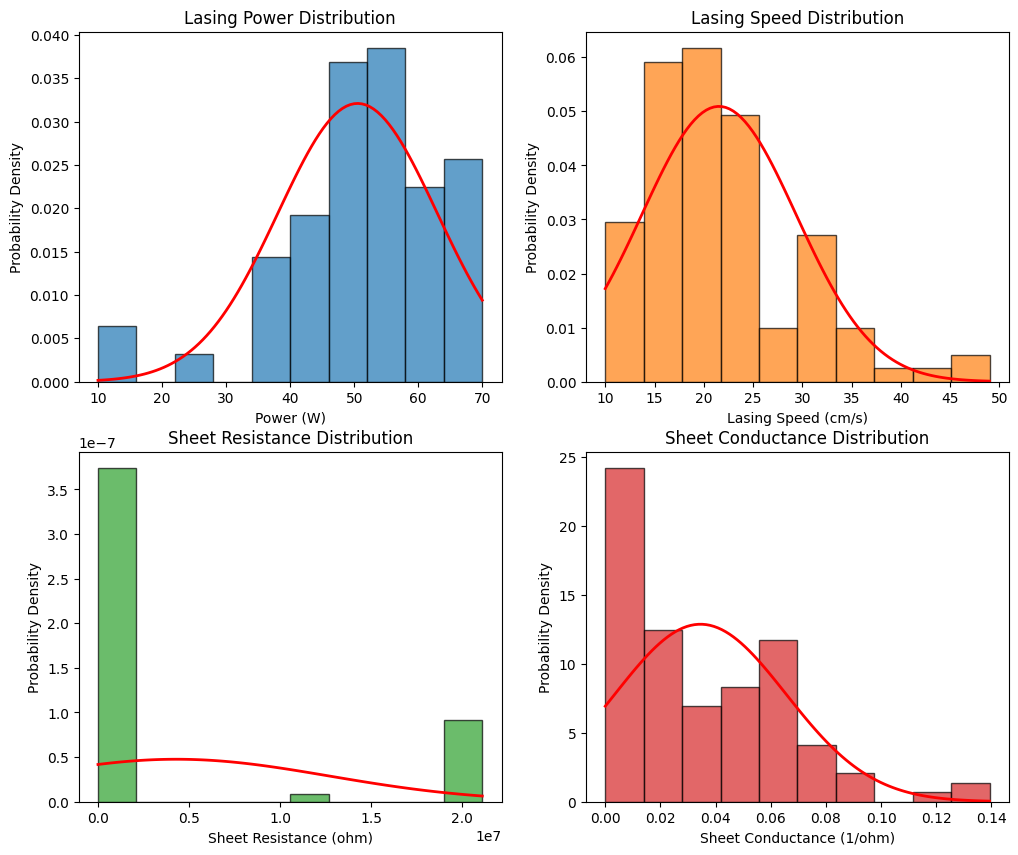

In [69]:
import matplotlib.pyplot as plt
from scipy.stats import norm

def gaussian(x, loc, s):
    return (1 / np.sqrt(2 * np.pi * s ** 2) * np.exp(-(x - loc) ** 2 / (2 * s ** 2)))

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.hist(Power, bins=10, density=True, alpha=0.7, color='C0', edgecolor='black')
x0_range = np.linspace(Power.min(), Power.max(), 100)
y0_values = gaussian(x0_range, Power.mean(), Power.std())
plt.plot(x0_range, y0_values, 'r-', linewidth=2, label='Custom Gaussian Fit')
plt.xlabel("Power (W)")
plt.ylabel("Probability Density")
plt.title("Lasing Power Distribution")

plt.subplot(2, 2, 2)
plt.hist(Speed, bins=10, density=True, alpha=0.7, color='C1', edgecolor='black')
x1_range = np.linspace(Speed.min(), Speed.max(), 100)
y1_values = gaussian(x1_range, Speed.mean(), Speed.std())
plt.plot(x1_range, y1_values, 'r-', linewidth=2, label='Custom Gaussian Fit')
plt.xlabel("Lasing Speed (cm/s)")
plt.ylabel("Probability Density")
plt.title("Lasing Speed Distribution")

plt.subplot(2, 2, 3)
plt.hist(Sheet_resistance, bins=10, density=True, alpha=0.7, color='C2', edgecolor='black')
x2_range = np.linspace(Sheet_resistance.min(), Sheet_resistance.max(), 100)
y2_values = gaussian(x2_range, Sheet_resistance.mean(), Sheet_resistance.std())
plt.plot(x2_range, y2_values, 'r-', linewidth=2, label='Custom Gaussian Fit')
plt.xlabel("Sheet Resistance (ohm)")
plt.ylabel("Probability Density")
plt.title("Sheet Resistance Distribution")

plt.subplot(2, 2, 4)
plt.hist(Sheet_conductance, bins=10, density=True, alpha=0.7, color='C3', edgecolor='black')
x3_range = np.linspace(Sheet_conductance.min(), Sheet_conductance.max(), 100)
y3_values = gaussian(x3_range, Sheet_conductance.mean(), Sheet_conductance.std())
plt.plot(x3_range, y3_values, 'r-', linewidth=2, label='Custom Gaussian Fit')
plt.xlabel("Sheet Conductance (1/ohm)")
plt.ylabel("Probability Density")
plt.title("Sheet Conductance Distribution")

plt.show()

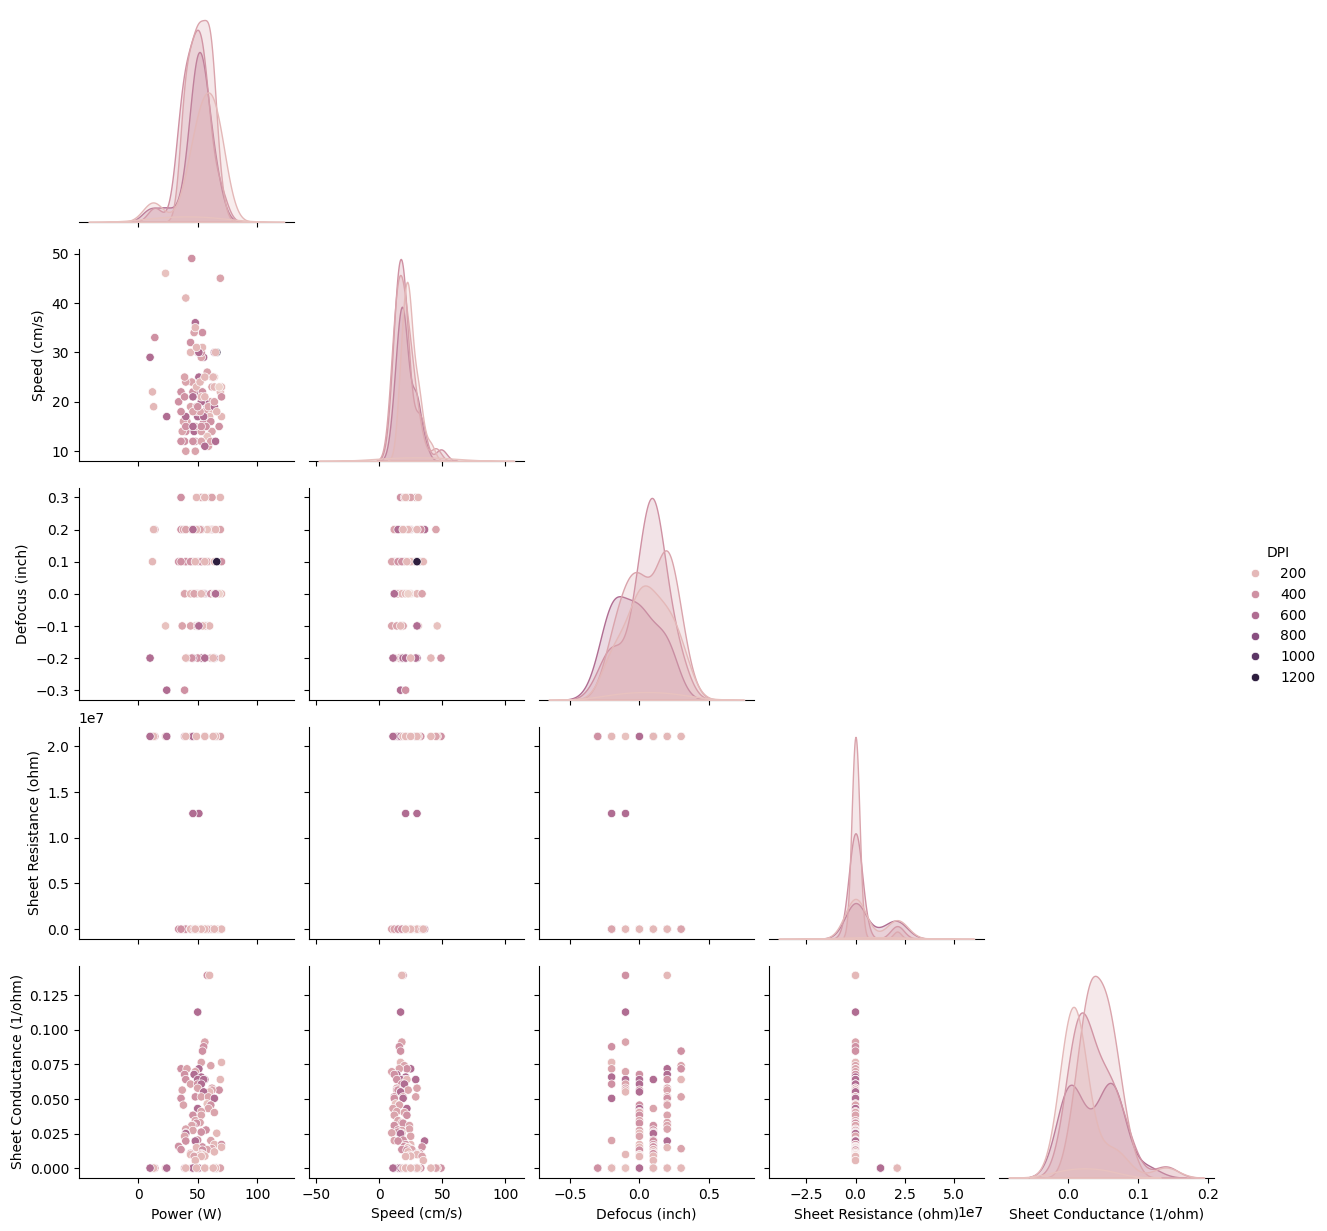

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the columns you want to visualize
cols = ["Power (W)", "Speed (cm/s)", "DPI", "Defocus (inch)",
        "Sheet Resistance (ohm)", "Sheet Conductance (1/ohm)"]

sns.pairplot(Data[cols], diag_kind="kde", corner=True, hue="DPI")
plt.show()

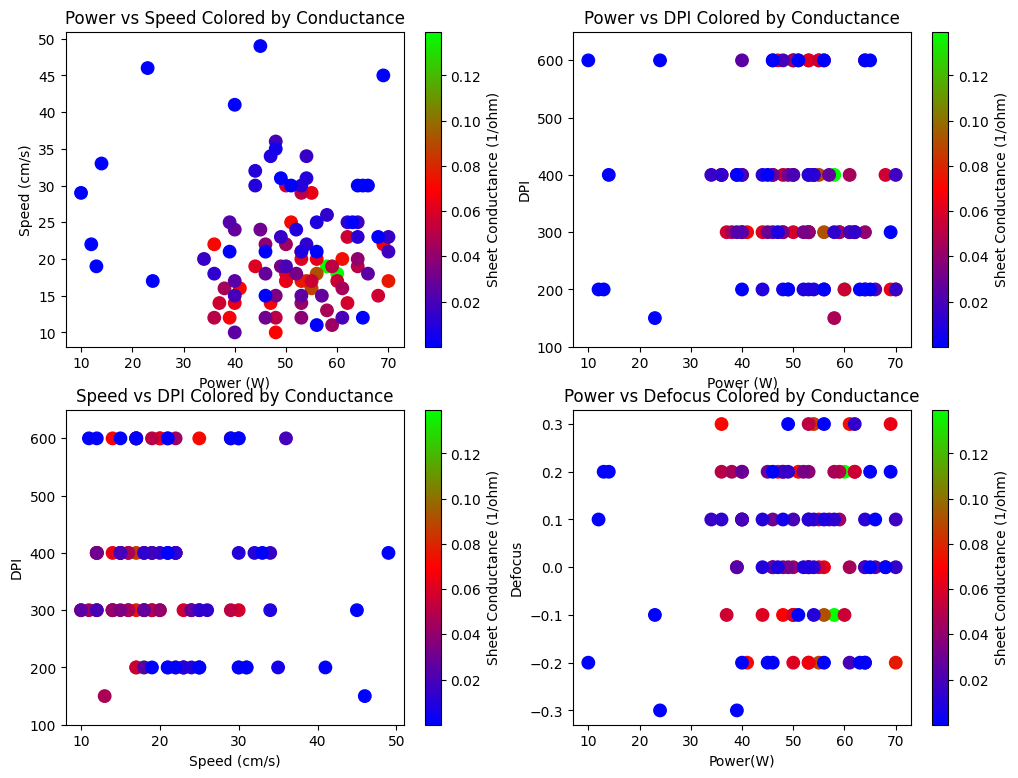

In [71]:
plt.figure(figsize=(12,9))
plt.subplot(2,2,1)
plt.scatter(Power, Speed, c=Sheet_conductance, cmap='brg', s=80)
plt.xlabel('Power (W)')
plt.ylabel('Speed (cm/s)')
plt.title('Power vs Speed Colored by Conductance')
cbar = plt.colorbar()
cbar.set_label('Sheet Conductance (1/ohm)')

plt.subplot(2,2,2)
plt.scatter(Power, DPI, c=Sheet_conductance, cmap='brg', s=80)
plt.xlabel('Power (W)')
plt.ylabel('DPI')
plt.ylim(100, 650)
plt.title('Power vs DPI Colored by Conductance')
cbar = plt.colorbar()
cbar.set_label('Sheet Conductance (1/ohm)')

plt.subplot(2,2,3)
plt.scatter(Speed, DPI, c=Sheet_conductance, cmap='brg', s=80)
plt.xlabel('Speed (cm/s)')
plt.ylabel('DPI')
plt.ylim(100, 650)
plt.title('Speed vs DPI Colored by Conductance')
cbar = plt.colorbar()
cbar.set_label('Sheet Conductance (1/ohm)')

plt.subplot(2,2,4)
plt.scatter(Power, Defocus, c=Sheet_conductance, cmap='brg', s=80)
plt.xlabel('Power(W)')
plt.ylabel('Defocus')
#plt.ylim(100, 650)
plt.title('Power vs Defocus Colored by Conductance')
cbar = plt.colorbar()
cbar.set_label('Sheet Conductance (1/ohm)')

plt.show()


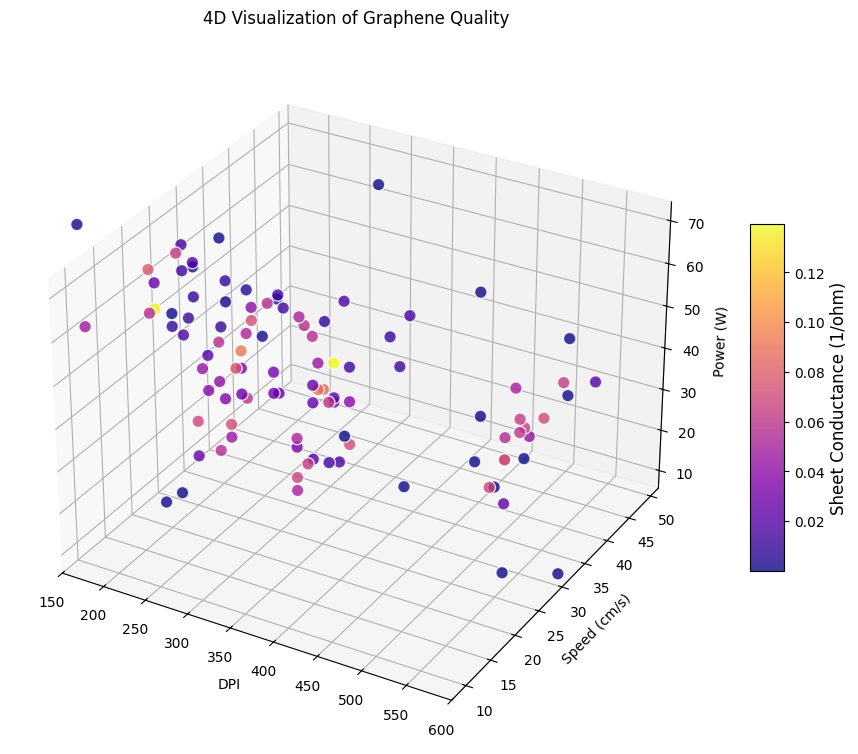

In [72]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Map the 4th variable (Conductance) to the color argument 'c'
# We use the variables you extracted in your previous code
img = ax.scatter(DPI, Speed, Power,
                 c=Sheet_conductance,
                 cmap='plasma',
                 s=80,
                 edgecolor='w',
                 alpha=0.8)

# Add a colorbar to decode the 4th dimension
cbar = fig.colorbar(img, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Sheet Conductance (1/ohm)', fontsize=12)

ax.set_xlim(150, 600)

# Set labels for the 3 spatial axes
ax.set_xlabel('DPI')
ax.set_ylabel('Speed (cm/s)')
ax.set_zlabel('Power (W)')
ax.set_title('4D Visualization of Graphene Quality', pad=20)

plt.show()

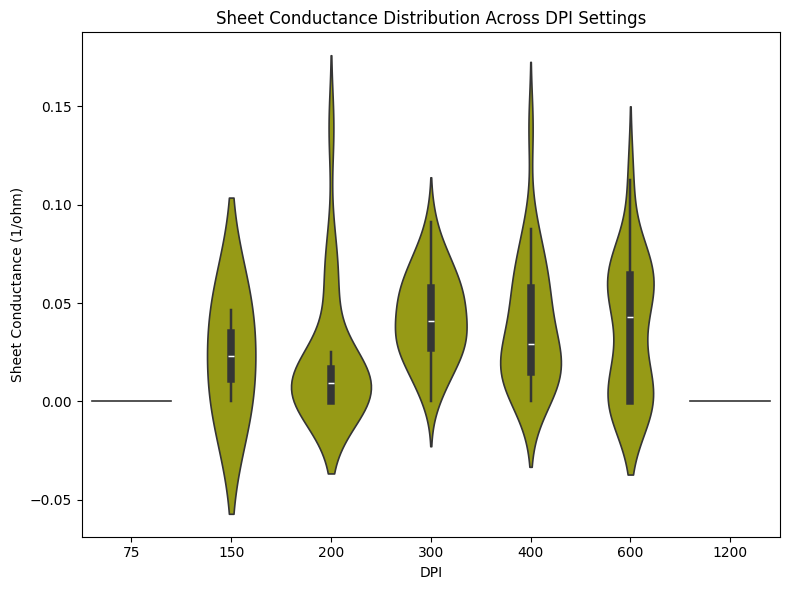

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=Data,
    x="DPI",
    y="Sheet Conductance (1/ohm)",
    inner="box",
    linewidth=1.2,
    color="#AAB000"
)

plt.title("Sheet Conductance Distribution Across DPI Settings")
plt.tight_layout()
plt.show()



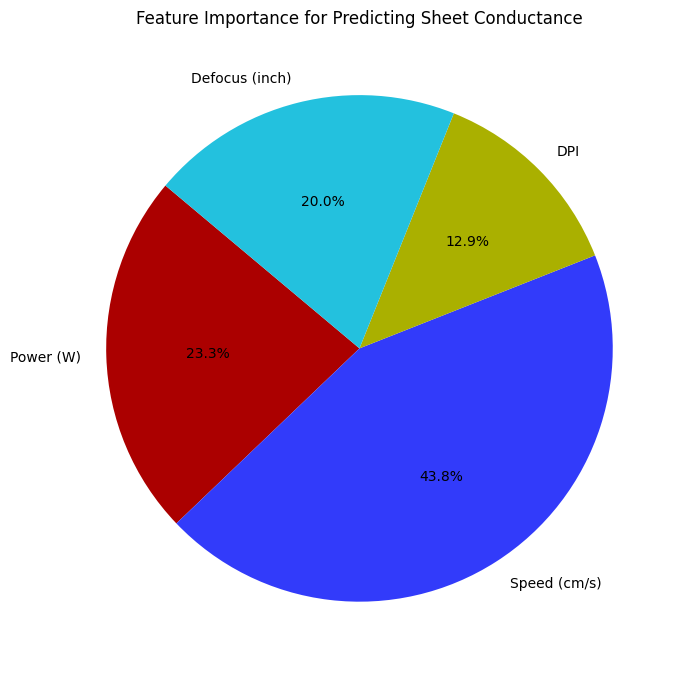

In [75]:
from sklearn.ensemble import RandomForestRegressor

X = Data[["Power (W)", "Speed (cm/s)", "DPI", "Defocus (inch)"]]
y = Data["Sheet Conductance (1/ohm)"]

rf = RandomForestRegressor(n_estimators=500, random_state=0)
rf.fit(X, y)

labels = X.columns
sizes = rf.feature_importances_

plt.figure(figsize=(7,7))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#AB0000", "#323BFA", "#AAB000", "#23C1DE"]
)
plt.title("Feature Importance for Predicting Sheet Conductance")
plt.tight_layout()
plt.show()


In [76]:
cor = np.corrcoef(Data.iloc[:, 0:6], rowvar=False)

# Print correlation matrix
print("Correlation Matrix:\n", cor)

Correlation Matrix:
 [[ 1.         -0.08243027 -0.04844783  0.0402033  -0.24559442  0.19143038]
 [-0.08243027  1.         -0.06834557 -0.00868319  0.38314103 -0.43226255]
 [-0.04844783 -0.06834557  1.         -0.16203456  0.11864047  0.0586956 ]
 [ 0.0402033  -0.00868319 -0.16203456  1.         -0.17260026  0.01304684]
 [-0.24559442  0.38314103  0.11864047 -0.17260026  1.         -0.571413  ]
 [ 0.19143038 -0.43226255  0.0586956   0.01304684 -0.571413    1.        ]]


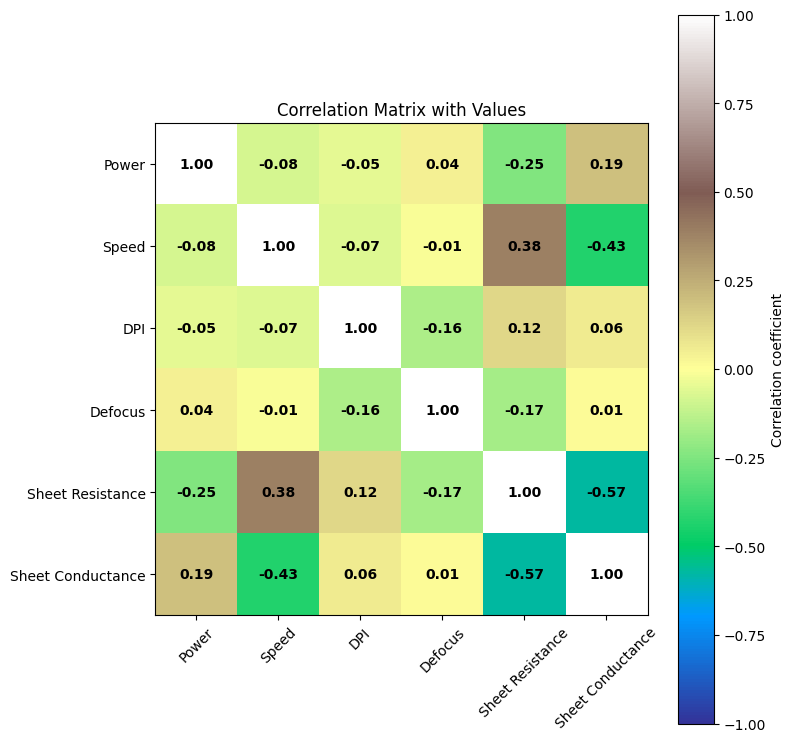

In [77]:
plt.figure(figsize=(8,8))
feature_names=['Power','Speed','DPI','Defocus','Sheet Resistance','Sheet Conductance']

# Create the heatmap
im = plt.imshow(cor, vmin=-1, vmax=1, cmap='terrain') # vmin=-1 better shows negative correlations
plt.colorbar(im, label="Correlation coefficient")

# --- ADDING THE VALUES ---
for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        # Displaying the value rounded to 2 decimal places
        # 'ha' and 'va' ensure the text is perfectly centered
        text = plt.text(j, i, f"{cor[i, j]:.2f}",
                       ha="center", va="center", color="black",
                       fontweight='bold')

# Formatting the axes
plt.xticks(range(len(feature_names)), feature_names, rotation=45)
plt.yticks(range(len(feature_names)), feature_names)
plt.title("Correlation Matrix with Values")
plt.tight_layout()
plt.show()